In [36]:
import time
import random
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

# CLASSICAL ALGORITHMS

In [37]:
# Searches through an unordered list one by one
def classical_linear_search(items, target):
    queries = 0
    for item in items:
        queries += 1
        if item == target:
            return queries, item
        
    return queries, None

In [ ]:
# Searches through a sorted list using binary search
def classical_binary_search(items, target):
    low, high = 0, len(items) - 1
    queries = 0
    while low <= high:
        queries += 1
        mid = (low + high) // 2
        if items[mid] == target:
            return queries, items[mid]
        elif items[mid] < target:
            low = mid + 1
        else:
            high = mid - 1
            
    return queries, None

# QUANTUM ALGORITHM (Grover)

In [39]:
# Oracle that marks the target state by flipping its phase.
def grover_oracle(n_qubits, target):
    qc = QuantumCircuit(n_qubits, name='oracle')

    target_bits = format(target, f'0{n_qubits}b')
    for i, bit in enumerate(reversed(target_bits)):     # qubit 0 = least significant bit
        if bit == '0':
            qc.x(i)

    # Multi-controlled Z: flips the phase of |11...1⟩
    qc.h(n_qubits - 1)
    qc.mcx(list(range(n_qubits - 1)), n_qubits - 1)
    qc.h(n_qubits - 1)

    for i, bit in enumerate(reversed(target_bits)):
        if bit == '0':
            qc.x(i)

    return qc

In [40]:
# Grover diffusion operator (reflection about the mean).
def grover_reflection(n_qubits):
    qc = QuantumCircuit(n_qubits, name='reflection')
    qc.h(range(n_qubits))
    qc.x(range(n_qubits))
    qc.h(n_qubits - 1)
    qc.mcx(list(range(n_qubits - 1)), n_qubits - 1)
    qc.h(n_qubits - 1)
    qc.x(range(n_qubits))
    qc.h(range(n_qubits))
    return qc

In [ ]:
# Grover search on the Aer simulator. Returns (n_iterations, counts, found, elapsed_time).
def grover_search(n_qubits, target, shots=1000):
    N = 2 ** n_qubits
    n_iterations = max(1, int(np.pi / 4 * np.sqrt(N)))  # optimal: π/4 · √N

    oracle     = grover_oracle(n_qubits, target)
    reflection = grover_reflection(n_qubits)

    qc = QuantumCircuit(n_qubits, n_qubits)
    qc.h(range(n_qubits))
    for _ in range(n_iterations):
        qc.append(oracle, range(n_qubits))
        qc.append(reflection, range(n_qubits))

    qc.measure(range(n_qubits), range(n_qubits))

    backend    = AerSimulator()
    transpiled = transpile(qc, backend)
    start_time = time.perf_counter()
    job        = backend.run(transpiled, shots=shots)
    counts     = job.result().get_counts()
    total_time = time.perf_counter() - start_time

    target_str = format(target, f'0{n_qubits}b')
    found = target_str in counts and counts[target_str] == max(counts.values())

    return n_iterations, counts, found, total_time

In [ ]:
# Grover search on real IBM hardware.
#   elapsed_total : submission -> completion  (includes queue wait)
#   elapsed_exec  : running -> completion     (circuit execution only)
#   target_prob   : fraction of shots on target  (noise indicator, 1.0 = ideal)
def grover_search_real(n_qubits, target, shots=1000):
    N = 2 ** n_qubits
    n_iterations = max(1, int(np.pi / 4 * np.sqrt(N)))

    oracle     = grover_oracle(n_qubits, target)
    reflection = grover_reflection(n_qubits)

    qc = QuantumCircuit(n_qubits, n_qubits)
    qc.h(range(n_qubits))
    for _ in range(n_iterations):
        qc.append(oracle, range(n_qubits))
        qc.append(reflection, range(n_qubits))

    qc.measure(range(n_qubits), range(n_qubits))

    service = QiskitRuntimeService()
    backend = service.least_busy(operational=True, simulator=False, min_num_qubits=n_qubits)
    print(f"  Using backend: {backend.name}  ({n_qubits} qubits needed)")

    pm         = generate_preset_pass_manager(backend=backend, optimization_level=1)
    transpiled = pm.run(qc)

    sampler  = Sampler(backend)
    t_submit = time.perf_counter()
    job      = sampler.run([transpiled], shots=shots)

    print(f"  Job ID: {job.job_id()}")
    t_running = None
    t_done    = None
    while True:
        status    = job.status()
        queue_pos = backend.status().pending_jobs
        now       = time.perf_counter()

        if t_running is None and 'RUNNING' in str(status).upper():
            t_running = now

        if queue_pos is not None:
            print(f"  Status: {status} | Queue position: {queue_pos}", end='\r')
        else:
            print(f"  Status: {status}", end='\r')
        if status in ('DONE', 'CANCELLED', 'ERROR'):
            t_done = now
            print()
            break
        
        time.sleep(10)

    elapsed_total = t_done - t_submit
    elapsed_exec  = t_done - (t_running if t_running is not None else t_submit)

    result = job.result()
    counts = result[0].data.c.get_counts()

    target_str  = format(target, f'0{n_qubits}b')
    found       = target_str in counts and counts[target_str] == max(counts.values())
    target_prob = counts.get(target_str, 0) / shots

    return n_iterations, counts, found, elapsed_total, elapsed_exec, backend.name, target_prob

# RUN COMPARISON

Real hardware is only run for n ≤ 5 (up to 32-element searches).

Beyond n = 5, the transpiled circuit depth grows rapidly because multi-controlled gates (MCX) decompose into many 2-qubit CNOT gates. The resulting circuit exceeds the coherence time of current IBM hardware, so the error rate becomes too high to produce meaningful results. Larger sizes are covered by simulation only.

In [43]:
qubit_range = range(2, 12)
results = {
    'n_qubits':                  [],
    'N':                         [],
    'linear_queries':            [],
    'binary_queries':            [],
    'grover_iters':              [],
    'linear_time':               [],
    'binary_time':               [],
    'grover_time':               [],
    'grover_correct':            [],
    'grover_real_time_total':    [],   # queue wait + circuit execution
    'grover_real_time_exec':     [],   # circuit execution only (no queue wait)
    'grover_real_correct':       [],
    'grover_real_prob':          [],   # fraction of shots measuring the target
    'grover_real_ran':           [],   # True if this case was run on real hardware
}

RUNS = 10  # Average over this many runs per size

for n in qubit_range:
    N = 2 ** n
    target = random.randint(0, N - 1)
    items_unordered = list(range(N))
    random.shuffle(items_unordered)
    items_ordered = sorted(items_unordered)

    print(f"n={n}, N={N}, target={target}")

    # Linear search
    lin_queries_total = 0
    lin_time_total = 0
    for _ in range(RUNS):
        random.shuffle(items_unordered)
        start = time.perf_counter()
        queries, _ = classical_linear_search(items_unordered, target)
        lin_time_total += time.perf_counter() - start
        lin_queries_total += queries

    # Binary search
    bin_queries_total = 0
    bin_time_total = 0
    for _ in range(RUNS):
        start = time.perf_counter()
        queries, _ = classical_binary_search(items_ordered, target)
        bin_time_total += time.perf_counter() - start
        bin_queries_total += queries

    # Simulated Grover, averaged over RUNS to match classical timing methodology
    g_time_total_sim = 0
    for _ in range(RUNS):
        n_iters, counts, correct, g_time = grover_search(n, target, shots=1000)
        g_time_total_sim += g_time
    g_time = g_time_total_sim / RUNS

    # Real Grover (only for n ≤ 5 - see note above)
    if n <= 5:
        _, _, correct_real, g_time_total, g_time_exec, _, prob_real = \
            grover_search_real(n, target, shots=1000)
        results['grover_real_time_total'].append(g_time_total)
        results['grover_real_time_exec'].append(g_time_exec)
        results['grover_real_correct'].append(correct_real)
        results['grover_real_prob'].append(prob_real)
        results['grover_real_ran'].append(True)
    else:
        results['grover_real_time_total'].append(None)
        results['grover_real_time_exec'].append(None)
        results['grover_real_correct'].append(None)
        results['grover_real_prob'].append(None)
        results['grover_real_ran'].append(False)

    results['n_qubits'].append(n)
    results['N'].append(N)
    results['linear_queries'].append(lin_queries_total / RUNS)
    results['binary_queries'].append(bin_queries_total / RUNS)
    results['grover_iters'].append(n_iters)
    results['linear_time'].append(lin_time_total / RUNS)
    results['binary_time'].append(bin_time_total / RUNS)
    results['grover_time'].append(g_time)
    results['grover_correct'].append(correct)

n=2, N=4, target=0
  Using backend: ibm_kingston  (2 qubits needed)
  Job ID: d7gi5bs93s0c738rj81g
  Status: DONE | Queue position: 0 0
n=3, N=8, target=7
  Using backend: ibm_kingston  (3 qubits needed)
  Job ID: d7gi5h3jne2c7392tt6g
  Status: DONE | Queue position: 0 0
n=4, N=16, target=9
  Using backend: ibm_kingston  (4 qubits needed)
  Job ID: d7gi5mbjne2c7392ttd0
  Status: DONE | Queue position: 0 0
n=5, N=32, target=5
  Using backend: ibm_kingston  (5 qubits needed)
  Job ID: d7gi5ra2khts739ohpkg
  Status: DONE | Queue position: 0 0
n=6, N=64, target=25
n=7, N=128, target=97
n=8, N=256, target=61
n=9, N=512, target=39
n=10, N=1024, target=839
n=11, N=2048, target=558


# PLOT 1 — Queries / Iterations

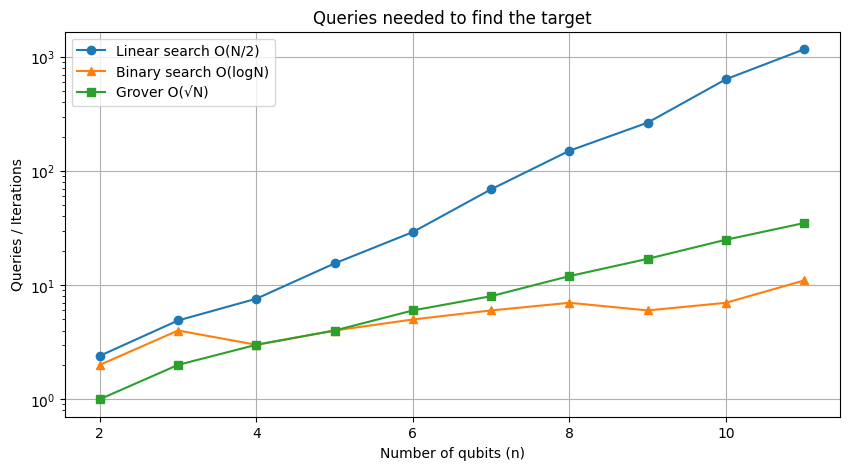

In [47]:
plt.figure(figsize=(10, 5))
plt.plot(results['n_qubits'], results['linear_queries'],  'o-', label='Linear search O(N/2)')
plt.plot(results['n_qubits'], results['binary_queries'],  '^-', label='Binary search O(logN)')
plt.plot(results['n_qubits'], results['grover_iters'],    's-', label='Grover O(√N)')
plt.xlabel('Number of qubits (n)')
plt.ylabel('Queries / Iterations')
plt.title('Queries needed to find the target')
plt.yscale('log')
plt.legend()
plt.grid(True)
plt.show()

# PLOT 2 — Actual execution time

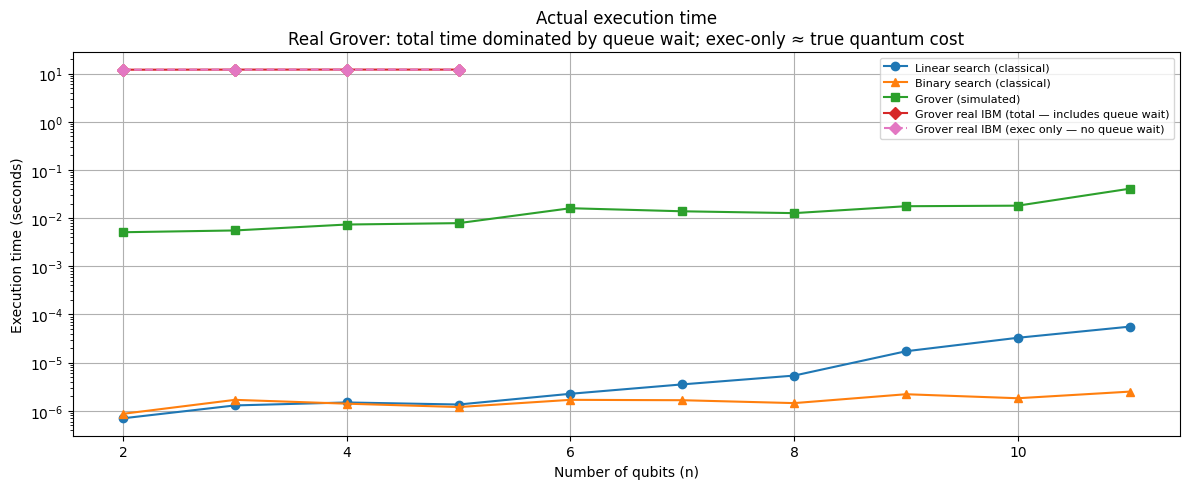

In [50]:
# Three quantum lines are shown for a complete picture:
#   Grover (simulated)       : classical simulation cost, grows with circuit size
#   Grover real (total)      : queue wait + execution, dominated by queue wait
#   Grover real (exec only)  : circuit execution time without queue wait
#                              this is the fairest comparison to the simulated line

plt.figure(figsize=(12, 5))
plt.plot(results['n_qubits'], results['linear_time'],  'o-', color='tab:blue',   label='Linear search (classical)')
plt.plot(results['n_qubits'], results['binary_time'],  '^-', color='tab:orange', label='Binary search (classical)')
plt.plot(results['n_qubits'], results['grover_time'],  's-', color='tab:green',  label='Grover (simulated)')

real_idx     = [i for i in range(len(results['n_qubits'])) if results['grover_real_ran'][i]]
real_n       = [results['n_qubits'][i]               for i in real_idx]
real_t_total = [results['grover_real_time_total'][i]  for i in real_idx]
real_t_exec  = [results['grover_real_time_exec'][i]   for i in real_idx]

plt.plot(real_n, real_t_total, 'D-',  color='tab:red',  label='Grover real IBM (total — includes queue wait)')
plt.plot(real_n, real_t_exec,  'D--', color='tab:pink', label='Grover real IBM (exec only — no queue wait)')

plt.xlabel('Number of qubits (n)')
plt.ylabel('Execution time (seconds)')
plt.title('Actual execution time\nReal Grover: total time dominated by queue wait; exec-only ≈ true quantum cost')
plt.yscale('log')
plt.legend(fontsize=8)
plt.grid(True)
plt.tight_layout()
plt.show()

# PRINT SUMMARY

In [49]:
print(f"\n{'n':>4} {'N':>6} {'Linear':>8} {'Binary':>8} {'Grover':>8} {'Correct':>8} {'Real total':>11} {'Real exec':>10} {'Correct':>8} {'Prob':>6}")
print("-" * 88)
for i in range(len(results['n_qubits'])):
    ran         = results['grover_real_ran'][i]
    t_total     = f"{results['grover_real_time_total'][i]:.2f}s" if ran else 'N/A'
    t_exec      = f"{results['grover_real_time_exec'][i]:.2f}s"  if ran else 'N/A'
    correct_str = 'Yes' if results['grover_real_correct'][i] else ('No' if ran else 'N/A')
    prob_str    = f"{results['grover_real_prob'][i]:.1%}" if ran else 'N/A'
    print(f"{results['n_qubits'][i]:>4} "
          f"{results['N'][i]:>6} "
          f"{results['linear_queries'][i]:>8.1f} "
          f"{results['binary_queries'][i]:>8.1f} "
          f"{results['grover_iters'][i]:>8} "
          f"{'Yes' if results['grover_correct'][i] else 'No':>8}"
          f"{t_total:>11} "
          f"{t_exec:>10} "
          f"{correct_str:>8} "
          f"{prob_str:>6}")


   n      N   Linear   Binary   Grover  Correct  Real total  Real exec  Correct   Prob
----------------------------------------------------------------------------------------
   2      4      2.4      2.0        1      Yes     12.01s     12.01s      Yes  98.0%
   3      8      4.9      4.0        2      Yes     12.07s     12.07s      Yes  71.0%
   4     16      7.6      3.0        3      Yes     12.09s     12.09s      Yes  47.4%
   5     32     15.5      4.0        4      Yes     12.07s     12.07s      Yes  13.5%
   6     64     29.2      5.0        6      Yes        N/A        N/A      N/A    N/A
   7    128     69.2      6.0        8      Yes        N/A        N/A      N/A    N/A
   8    256    150.6      7.0       12      Yes        N/A        N/A      N/A    N/A
   9    512    265.6      6.0       17      Yes        N/A        N/A      N/A    N/A
  10   1024    637.8      7.0       25      Yes        N/A        N/A      N/A    N/A
  11   2048   1167.1     11.0       35      Yes  